# Phase A — Stage 2 (two variants + leakage controls)

REVIEW_PLAN.md **Stage 2**. Keeps the tri-modal InfoNCE alignment, adds:

* **Variant A** — baseline. `proj_dim` 256 → **128** (folds 1–2 stopped at ep ~4–14 = capacity red flag).
* **Variant B** — metastasis-aware. Variant A **+ an auxiliary head** that regresses the
  Stage-1A leaving-program score from the *vision projection* (small weight). This *pushes*
  the projector to preserve the metastasis subspace that whole-transcriptome alignment may wash out.

**Leakage controls**
* Batch-balanced InfoNCE sampling across the 6 slides (no slide-identity shortcut).
* Retrieval reported **with spatial neighbours excluded** from the candidate pool (raw also reported).

**Decision gate** — pick the variant whose **held-out vision→leaving-program** prediction is best
(ridge probe trained on training-patient vision embeddings, evaluated on the held-out PT patient).
Then scale the winner to UNI2-h (1536d) by changing `VISION_DIR`.

Runs **both variants** in one pass and prints an A-vs-B comparison at the end.


In [37]:
import warnings
import os

# Suppress standard Python warnings
warnings.filterwarnings("ignore")

# Suppress PyTorch/multiprocessing environment-level warnings if needed
os.environ["PYTHONWARNINGS"] = "ignore"

In [38]:
# Imports
import os, json, random, copy, math
from dataclasses import dataclass, asdict, field
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr

print("Torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU  :", torch.cuda.get_device_name(0))


Torch: 2.10.0+cu128 | CUDA: True
GPU  : Tesla T4


In [39]:
# Configuration
@dataclass
class Config:
    # Embedding dirs (Kaggle defaults; local overridden below)
    VISION_DIR:  str ="/kaggle/input/datasets/wanianaeem/zenodo-pt-and-hm-dataset/Feature Extraction Embeddings/UNI2-h"
    GENE_DIR:    str = "/kaggle/input/datasets/wanianaeem/zenodo-pt-and-hm-dataset/scvi_latent_pt_embeddings/scvi_latent_pt_embeddings"
    CELL_DIR:    str = "/kaggle/input/datasets/wanianaeem/zenodo-pt-and-hm-dataset/Cell Embedding Extraction/RCTD/RCTD_embeddings/Features/RCTD"
    QC_MASK_CSV: str = "/kaggle/input/datasets/wanianaeem/zenodo-pt-and-hm-dataset/build_qc_mask.py"
    # Stage-1A target — ADD leaving_program_scores.csv to the Kaggle dataset root.
    LEAVING_CSV: str = "/kaggle/input/datasets/wanianaeem/zenodo-pt-and-hm-dataset/leaving_program_scores.csv"
    output_dir:  str = "/kaggle/working/stage2"
    MIN_GENES:  int = 200
    MIN_COUNTS: int = 400
    n_folds:    int = 6

    # Model — Stage 2: proj_dim 256 -> 128
    proj_dim:    int   = 128
    dropout:     float = 0.30
    temperature: float = 0.07

    weight_vg: float = 2.0
    weight_vc: float = 2.0
    weight_gc: float = 1.0

    # Variant B auxiliary head (ignored for Variant A)
    aux_weight: float = 0.3                       # 0.2-0.5 per plan
    aux_target: str   = "leaving_score_resid"     # headline (confound-free); "leaving_score" = raw

    # Leakage controls
    balanced_sampling: bool = True                # batch-balanced across slides
    retrieval_excl_radius: int = 2                # exclude same-sample spots within Chebyshev<=R

    # Training
    seed:               int   = 42
    epochs:             int   = 200
    batch_size:         int   = 512
    num_workers:        int   = 0
    lr:                 float = 3e-4
    weight_decay:       float = 5e-2
    patience:           int   = 10
    min_delta:          float = 1e-3
    warmup_epochs:      int   = 5
    grad_clip:          float = 1.0
    amp:                bool  = True
    accumulation_steps: int   = 8

cfg = Config()

# Which variants to run in this pass
VARIANTS_TO_RUN = ["A", "B"]

# ── Local path auto-detection ────────────────────────────────────────────────
IS_KAGGLE = os.path.exists("/kaggle/working")
if not IS_KAGGLE:
    # find project root: walk up until a folder containing "dataset" is found
    p = Path.cwd()
    root = None
    for cand in [p, *p.parents]:
        if (cand / "dataset").exists() and (cand / "Outputs").exists():
            root = cand; break
    if root is None:
        root = Path.cwd().parent       # fallback (notebook in 04_Models)
    cfg.VISION_DIR  = str(root / "dataset/Feature Extraction Embeddings/UNI2-h")
    cfg.GENE_DIR    = str(root / "dataset/Gene Embedding Extraction/scvi_latent_pt_embeddings")
    cfg.CELL_DIR    = str(root / "dataset/Cell Embedding Extraction/RCTD")
    cfg.QC_MASK_CSV = str(root / "/kaggle/input/datasets/wanianaeem/zenodo-pt-and-hm-dataset/spot_qc_mask.csv")
    cfg.LEAVING_CSV = str(root / "/kaggle/input/datasets/wanianaeem/zenodo-pt-and-hm-dataset/leaving_program_scores.csv")
    cfg.output_dir  = str(root / "Outputs/stage2")
    cfg.num_workers = 0   # Windows notebook safe

os.makedirs(cfg.output_dir, exist_ok=True)

print(f"Running : {'Kaggle' if IS_KAGGLE else 'local'}")
print(f"VISION  : {cfg.VISION_DIR}")
print(f"GENE    : {cfg.GENE_DIR}")
print(f"CELL    : {cfg.CELL_DIR}")
print(f"QC mask : {cfg.QC_MASK_CSV}")
print(f"LEAVING : {cfg.LEAVING_CSV}  (exists={os.path.exists(cfg.LEAVING_CSV)})")
print(f"Output  : {cfg.output_dir}")
print(f"Variants: {VARIANTS_TO_RUN}   proj_dim={cfg.proj_dim}  aux_weight={cfg.aux_weight}  aux_target={cfg.aux_target}")

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(cfg.seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device  :", device)

# Where to hunt for the CSVs if the hard-coded path is wrong/nested
SEARCH_ROOTS = ["/kaggle/input"] if IS_KAGGLE else [str(Path(cfg.QC_MASK_CSV).parents[1]),
                                                    str(Path(cfg.LEAVING_CSV).parents[1])]

def _read_csv_safe(path, **kw):
    """Read a CSV tolerant to a stray bad row / odd quoting (Kaggle pandas is strict)."""
    try:
        return pd.read_csv(path, **kw)
    except Exception:
        return pd.read_csv(path, engine="python", on_bad_lines="skip", **kw)

def locate_csv(preferred, required_cols, label):
    """Return a CSV path that actually contains required_cols. Falls back to a
    recursive search of SEARCH_ROOTS — robust to wrong/nested Kaggle dataset paths."""
    cands = []
    if preferred and os.path.exists(preferred):
        cands.append(preferred)
    for r in SEARCH_ROOTS:
        if os.path.isdir(r):
            cands += [str(p) for p in Path(r).rglob("*.csv")]
    seen = set()
    for c in cands:
        if c in seen:
            continue
        seen.add(c)
        try:
            head = _read_csv_safe(c, nrows=5)
        except Exception:
            continue
        if all(col in head.columns for col in required_cols):
            if c != preferred:
                print(f"  [locate_csv] {label}: using '{c}' (preferred path was wrong/missing)")
            return c
    print(f"  [locate_csv] {label}: NO csv with columns {required_cols} found under {SEARCH_ROOTS}")
    return None


Running : Kaggle
VISION  : /kaggle/input/datasets/wanianaeem/zenodo-pt-and-hm-dataset/Feature Extraction Embeddings/UNI2-h
GENE    : /kaggle/input/datasets/wanianaeem/zenodo-pt-and-hm-dataset/scvi_latent_pt_embeddings/scvi_latent_pt_embeddings
CELL    : /kaggle/input/datasets/wanianaeem/zenodo-pt-and-hm-dataset/Cell Embedding Extraction/RCTD/RCTD_embeddings/Features/RCTD
QC mask : /kaggle/input/datasets/wanianaeem/zenodo-pt-and-hm-dataset/build_qc_mask.py
LEAVING : /kaggle/input/datasets/wanianaeem/zenodo-pt-and-hm-dataset/leaving_program_scores.csv  (exists=True)
Output  : /kaggle/working/stage2
Variants: ['A', 'B']   proj_dim=128  aux_weight=0.3  aux_target=leaving_score_resid
Device  : cuda


In [40]:
# Dataset
def load_embedding_file(path):
    obj = torch.load(path, map_location="cpu")
    if isinstance(obj, dict):
        for key in ["embedding", "embeddings", "latent", "x", "z"]:
            if key in obj:
                obj = obj[key]; break
        else:
            obj = next(v for v in obj.values() if torch.is_tensor(v))
    if isinstance(obj, np.ndarray):
        obj = torch.from_numpy(obj)
    return obj.float().reshape(-1)

In [41]:
# Build aligned records (+ QC mask + Stage-1A leaving target + row/col)
def parse_rowcol(stem):
    """patch_stem suffix is ..._{row}_{col}."""
    parts = stem.split("_")
    try:
        return int(parts[-2]), int(parts[-1])
    except Exception:
        return -1, -1

# QC mask  (auto-located by columns — robust to wrong/nested Kaggle paths)
qc_dict = {}
qc_path = locate_csv(cfg.QC_MASK_CSV, ["patch_stem", "nFeature", "nCount"], "QC mask")
if qc_path:
    _qc = _read_csv_safe(qc_path)
    _qc = _qc.dropna(subset=["patch_stem", "nFeature", "nCount"])
    qc_dict = {row["patch_stem"]: (int(row["nFeature"]), int(row["nCount"]))
               for _, row in _qc.iterrows()}
    _pass = sum(1 for nf, nc in qc_dict.values()
                if nf >= cfg.MIN_GENES and nc >= cfg.MIN_COUNTS)
    print(f"QC mask : {len(qc_dict):,} patches, {_pass:,} pass {cfg.MIN_GENES}/{cfg.MIN_COUNTS}")
else:
    print("QC mask not found — modality inner-join only.")

# Stage-1A leaving targets (PT spots only). Standardise over PT spots so the
# aux MSE is on comparable scale to InfoNCE regardless of raw/resid choice.
leave_raw, leave_resid = {}, {}
leaving_path = locate_csv(cfg.LEAVING_CSV,
                          ["patch_stem", "leaving_score", "leaving_score_resid"], "leaving CSV")
if leaving_path:
    _lv = _read_csv_safe(leaving_path)
    tgt = cfg.aux_target
    assert tgt in _lv.columns, f"{tgt} not in leaving CSV cols {list(_lv.columns)}"
    mu, sd = _lv[tgt].mean(), _lv[tgt].std() + 1e-8
    for _, r in _lv.iterrows():
        leave_resid[r["patch_stem"]] = float((r[tgt] - mu) / sd)
    print(f"Leaving : {len(leave_resid):,} PT spots scored on '{tgt}' (z-scored, mu={mu:.3f} sd={sd:.3f})")
    # also keep BOTH raw & resid in original units for the ridge probe (decision gate)
    leave_cols = {row["patch_stem"]: (float(row["leaving_score"]), float(row["leaving_score_resid"]))
                  for _, row in _lv.iterrows()}
else:
    print("WARNING: leaving CSV not found — Variant B aux head will have no target (skip Variant B).")
    leave_cols = {}

# Index gene/cell files
gene_dict = {f.stem: str(f) for f in sorted(Path(cfg.GENE_DIR).rglob("*.pt"))}
cell_dict = {f.stem: str(f) for f in sorted(Path(cfg.CELL_DIR).rglob("*.pt"))}
print(f"Gene .pt: {len(gene_dict):,}  | Cell .pt: {len(cell_dict):,}")

# 2. Preload files directly into dictionary memory mapping
gene_loaded = {}
for stem, path in tqdm(gene_dict.items(), desc="Loading Genes to RAM"):
    gene_loaded[stem] = load_embedding_file(path)

cell_loaded = {}
for stem, path in tqdm(cell_dict.items(), desc="Loading Cells to RAM"):
    cell_loaded[stem] = load_embedding_file(path)

# 3. Re-build pairs list using the in-memory tensors
pairs, qc_rejected = [], 0

for vf in sorted(Path(cfg.VISION_DIR).rglob("*.pt")):
    sd_ = torch.load(vf, map_location="cpu")
    patient, embs, names = sd_["patient"], sd_["embeddings"], sd_["patch_names"]
    
    matched = 0
    for idx, raw_name in enumerate(names):
        name = Path(str(raw_name)).stem
        if name not in gene_loaded or name not in cell_loaded:
            continue
            
        if qc_dict:
            qc = qc_dict.get(name)
            if qc is None or qc[0] < cfg.MIN_GENES or qc[1] < cfg.MIN_COUNTS:
                qc_rejected += 1
                continue
                
        row, col = parse_rowcol(name)
        has_leave = name in leave_resid
        
        pairs.append({
            "id": name,
            "sample": patient,
            "vision": embs[idx],
            "gene": gene_loaded[name],    # Storing the actual preloaded tensor
            "cell": cell_loaded[name],    # Storing the actual preloaded tensor
            "row": row, 
            "col": col,
            "leaving": leave_resid.get(name, 0.0),
            "has_leave": 1.0 if has_leave else 0.0,
            "leave_raw": leave_cols.get(name, (np.nan, np.nan))[0],
            "leave_resid": leave_cols.get(name, (np.nan, np.nan))[1],
        })
        matched += 1
    print(f"  {patient}: {len(names)} patches -> {matched} aligned")

print(f"\nQC-rejected: {qc_rejected:,} | Total aligned & preloaded: {len(pairs):,}")


# ==========================================
# UPDATE CELL [5]: NEW DATASET DEFINITION
# ==========================================

class TriModalDataset(Dataset):
    """Each record carries vision, gene, and cell tensors completely preloaded 
    in memory to ensure maximum GPU data delivery saturation."""
    def __init__(self, records):
        self.records = records
        
    def __len__(self):
        return len(self.records)
        
    def __getitem__(self, idx):
        r = self.records[idx]
        return {
            "id":        r["id"],
            "vision":    r["vision"].float(),
            "gene":      r["gene"].float(),  # Instant retrieval from RAM
            "cell":      r["cell"].float(),  # Instant retrieval from RAM
            "leaving":   torch.tensor(r["leaving"], dtype=torch.float32),
            "has_leave": torch.tensor(r["has_leave"], dtype=torch.float32),
        }

  [locate_csv] QC mask: using '/kaggle/input/datasets/wanianaeem/zenodo-pt-and-hm-dataset/spot_qc_mask.csv' (preferred path was wrong/missing)
QC mask : 20,395 patches, 18,859 pass 200/400
Leaving : 13,578 PT spots scored on 'leaving_score_resid' (z-scored, mu=0.000 sd=1.000)
Gene .pt: 18,859  | Cell .pt: 20,395


Loading Genes to RAM:   0%|          | 0/18859 [00:00<?, ?it/s]

Loading Cells to RAM:   0%|          | 0/20395 [00:00<?, ?it/s]

  IU_PDA_HM11: 3931 patches -> 3894 aligned
  IU_PDA_HM13: 2182 patches -> 1387 aligned
  IU_PDA_T11: 2777 patches -> 2677 aligned
  IU_PDA_T1: 3530 patches -> 3073 aligned
  IU_PDA_T3: 4354 patches -> 4241 aligned
  IU_PDA_T4: 3621 patches -> 3587 aligned

QC-rejected: 0 | Total aligned & preloaded: 18,859


In [42]:
# Sample-level split (6-fold LOSO + cohort-transfer)
SAMPLE_MAP = {
    "IU_PDA_HM11": "HM11", "IU_PDA_HM13": "HM13",
    "IU_PDA_T1": "T1", "IU_PDA_T3": "T3", "IU_PDA_T4": "T4", "IU_PDA_T11": "T11",
}
spot_samples = np.array([SAMPLE_MAP.get(p["sample"], p["sample"]) for p in pairs])
spot_rows    = np.array([p["row"] for p in pairs])
spot_cols    = np.array([p["col"] for p in pairs])

unmatched = set(np.unique(spot_samples)) - set(SAMPLE_MAP.values())
if unmatched:
    print("WARNING unmatched sample IDs:", sorted(unmatched))
else:
    print("SAMPLE_MAP OK")

us, cnts = np.unique(spot_samples, return_counts=True)
print("Per-sample spots:", {s: int(c) for s, c in zip(us, cnts)})

PT_SAMPLES = ["T1", "T3", "T4", "T11"]
HM_SAMPLES = ["HM11", "HM13"]
FOLD_DEFS = [
    {"val": ["HM11"], "train": ["HM13", "T1", "T3", "T4", "T11"]},   # Fold 1 HM holdout
    {"val": ["HM13"], "train": ["HM11", "T1", "T3", "T4", "T11"]},   # Fold 2 HM holdout
    {"val": ["T1"],   "train": ["HM11", "HM13", "T3", "T4", "T11"]}, # Fold 3 PT holdout
    {"val": ["T3"],   "train": ["HM11", "HM13", "T1", "T4", "T11"]}, # Fold 4
    {"val": ["T4"],   "train": ["HM11", "HM13", "T1", "T3", "T11"]}, # Fold 5
    {"val": ["T11"],  "train": ["HM11", "HM13", "T1", "T3", "T4"]},  # Fold 6 (T11+HM11 matched)
]
COHORT_FOLD_DEF = {"val": HM_SAMPLES, "train": PT_SAMPLES}

for i, fd in enumerate(FOLD_DEFS, 1):
    tr = int(np.isin(spot_samples, fd["train"]).sum())
    vl = int(np.isin(spot_samples, fd["val"]).sum())
    tag = " * HM holdout" if i <= 2 else (" [T11+HM11 matched]" if i == 6 else "")
    print(f"  Fold {i} | train {tr:>5} {fd['train']} | val {vl:>5} {fd['val']}{tag}")

full_dataset = TriModalDataset(pairs)
_s = full_dataset[0]
vision_dim, gene_dim, cell_dim = _s["vision"].shape[0], _s["gene"].shape[0], _s["cell"].shape[0]
print(f"\nDims — vision:{vision_dim} gene:{gene_dim} cell:{cell_dim}")


SAMPLE_MAP OK
Per-sample spots: {np.str_('HM11'): 3894, np.str_('HM13'): 1387, np.str_('T1'): 3073, np.str_('T11'): 2677, np.str_('T3'): 4241, np.str_('T4'): 3587}
  Fold 1 | train 14965 ['HM13', 'T1', 'T3', 'T4', 'T11'] | val  3894 ['HM11'] * HM holdout
  Fold 2 | train 17472 ['HM11', 'T1', 'T3', 'T4', 'T11'] | val  1387 ['HM13'] * HM holdout
  Fold 3 | train 15786 ['HM11', 'HM13', 'T3', 'T4', 'T11'] | val  3073 ['T1']
  Fold 4 | train 14618 ['HM11', 'HM13', 'T1', 'T4', 'T11'] | val  4241 ['T3']
  Fold 5 | train 15272 ['HM11', 'HM13', 'T1', 'T3', 'T11'] | val  3587 ['T4']
  Fold 6 | train 16182 ['HM11', 'HM13', 'T1', 'T3', 'T4'] | val  2677 ['T11'] [T11+HM11 matched]

Dims — vision:1536 gene:50 cell:15


In [43]:
# Model — TriModalBridge (+ optional Variant-B aux head)
class MLPProjector(nn.Module):
    def __init__(self, input_dim, hidden_dims, proj_dim, dropout):
        super().__init__()
        layers, in_d = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(in_d, h), nn.GELU(), nn.LayerNorm(h), nn.Dropout(dropout)]
            in_d = h
        layers += [nn.Linear(in_d, proj_dim), nn.Dropout(dropout * 0.5)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)


class TriModalBridge(nn.Module):
    def __init__(self, vision_dim, gene_dim, cell_dim, cfg, use_aux=False):
        super().__init__()
        j, d = cfg.proj_dim, cfg.dropout
        self.Pv = MLPProjector(vision_dim, [768, 384], j, d)
        self.Pg = MLPProjector(gene_dim,   [256],      j, d)
        self.Pc = MLPProjector(cell_dim,   [128],      j, d)
        init = torch.log(torch.tensor(cfg.temperature))
        self.log_temp_vg = nn.Parameter(init.clone())
        self.log_temp_vc = nn.Parameter(init.clone())
        self.log_temp_gc = nn.Parameter(init.clone())
        self.use_aux = use_aux
        if use_aux:
            # regress the leaving-program score from the (normalised) vision projection
            self.aux = nn.Sequential(
                nn.Linear(j, j // 2), nn.GELU(), nn.Dropout(d), nn.Linear(j // 2, 1)
            )
    def temperatures(self):
        return {"t_vg": self.log_temp_vg.clamp(-4.6, -0.7).exp().item(),
                "t_vc": self.log_temp_vc.clamp(-4.6, -0.7).exp().item(),
                "t_gc": self.log_temp_gc.clamp(-4.6, -0.7).exp().item()}
    def forward(self, vision, gene, cell):
        return self.Pv(vision), self.Pg(gene), self.Pc(cell)
    def aux_predict(self, zv):
        return self.aux(zv).squeeze(-1)


def build_model(use_aux):
    m = TriModalBridge(vision_dim, gene_dim, cell_dim, cfg, use_aux=use_aux).to(device)
    n = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"  model params: {n:,}  (use_aux={use_aux})")
    return m


In [44]:
# Loss — tri-modal InfoNCE (+ optional aux MSE on PT spots)
def infonce(a, b, log_temp):
    temp = log_temp.clamp(-4.6, -0.7).exp()
    logits = (a @ b.T) / temp
    labels = torch.arange(a.size(0), device=a.device)
    return 0.5 * (F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels))


def tri_modal_loss(zv, zg, zc, model, cfg):
    l_vg = infonce(zv, zg, model.log_temp_vg)
    l_vc = infonce(zv, zc, model.log_temp_vc)
    l_gc = infonce(zg, zc, model.log_temp_gc)
    tw = cfg.weight_vg + cfg.weight_vc + cfg.weight_gc
    loss = (cfg.weight_vg * l_vg + cfg.weight_vc * l_vc + cfg.weight_gc * l_gc) / tw
    return loss, {"vg": l_vg.item(), "vc": l_vc.item(), "gc": l_gc.item()}


def aux_loss_fn(model, zv, leaving, has_leave):
    """Masked MSE — only PT spots (has_leave==1) contribute."""
    pred = model.aux_predict(zv)
    m = has_leave > 0.5
    if m.sum() < 2:
        return zv.new_tensor(0.0)
    return F.mse_loss(pred[m], leaving[m])


In [45]:
# Early stopping, batch-balanced sampler, scheduler
class EarlyStopping:
    def __init__(self, patience, min_delta, path):
        self.patience, self.min_delta, self.path = patience, min_delta, path
        self.best_loss, self.counter, self.best_epoch = float("inf"), 0, -1
    def step(self, val_loss, model, epoch):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss, self.best_epoch, self.counter = val_loss, epoch, 0
            torch.save(model.state_dict(), self.path)
            return False
        self.counter += 1
        return self.counter >= self.patience


def make_balanced_sampler(sub_idx):
    """WeightedRandomSampler so each batch is ~uniform over the training slides
    (no slide-identity shortcut in InfoNCE negatives)."""
    labs = spot_samples[sub_idx]
    us, cnt = np.unique(labs, return_counts=True)
    w_per = {s: 1.0 / c for s, c in zip(us, cnt)}
    weights = torch.tensor([w_per[s] for s in labs], dtype=torch.double)
    return WeightedRandomSampler(weights, num_samples=len(sub_idx), replacement=True)


def make_warmup_cosine(opt, warmup, total, eta_min_ratio):
    cos = max(total - warmup, 1)
    def f(ep):
        if ep < warmup:
            return (ep + 1) / warmup
        prog = (ep - warmup) / cos
        return eta_min_ratio + (1 - eta_min_ratio) * 0.5 * (1 + np.cos(np.pi * prog))
    return torch.optim.lr_scheduler.LambdaLR(opt, f)


In [46]:
# Single-epoch runner (handles aux head)
def run_epoch(model, loader, cfg, optimizer=None, scaler=None, train=True, use_aux=False):
    model.train(train)
    total_loss, total_n = 0.0, 0
    acc = cfg.accumulation_steps if train else 1
    pbar = tqdm(loader, desc="train" if train else "val ", leave=False)
    for i, batch in enumerate(pbar):
        vision = batch["vision"].to(device, non_blocking=True)
        gene   = batch["gene"].to(device, non_blocking=True)
        cell   = batch["cell"].to(device, non_blocking=True)
        leaving   = batch["leaving"].to(device, non_blocking=True)
        has_leave = batch["has_leave"].to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=(cfg.amp and device.type == "cuda")):
            zv, zg, zc = model(vision, gene, cell)
            loss, parts = tri_modal_loss(zv, zg, zc, model, cfg)
            if use_aux:
                la = aux_loss_fn(model, zv, leaving, has_leave)
                loss = loss + cfg.aux_weight * la
            else:
                la = torch.tensor(0.0)

        if train:
            loss = loss / acc
            scaler.scale(loss).backward()
            if (i + 1) % acc == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
                scaler.step(optimizer); scaler.update()
                optimizer.zero_grad(set_to_none=True)

        bs = vision.size(0)
        total_loss += loss.item() * bs * (acc if train else 1)
        total_n += bs
        pbar.set_postfix(loss=f"{loss.item()*(acc if train else 1):.3f}",
                         aux=f"{(la.item() if torch.is_tensor(la) else la):.3f}")
    return total_loss / total_n


In [47]:
# Eval — projections, retrieval (naive + spatial-neighbour-excluded), ridge probe
@torch.no_grad()
def extract_projections(model, loader):
    model.eval()
    V, G, C, ids = [], [], [], []
    for b in tqdm(loader, desc="extract", leave=False):
        zv, zg, zc = model(b["vision"].to(device), b["gene"].to(device), b["cell"].to(device))
        V.append(zv.cpu()); G.append(zg.cpu()); C.append(zc.cpu()); ids.extend(b["id"])
    return torch.cat(V), torch.cat(G), torch.cat(C), ids


def _ranks(sims):
    target = torch.arange(sims.size(0)).unsqueeze(1)
    order = sims.argsort(dim=1, descending=True)
    return (order == target).float().argmax(dim=1) + 1  # 1-indexed rank of true match


def retrieval_from_sims(sims, ks=(1, 5, 10)):
    ranks = _ranks(sims)
    out = {f"R@{k}": (ranks <= k).float().mean().item() for k in ks}
    out["MRR"] = (1.0 / ranks.float()).mean().item()
    return out


def build_excl_mask(rows, cols, samples, R):
    """True where candidate must be SUPPRESSED: same sample, Chebyshev<=R, not self."""
    rows = np.asarray(rows); cols = np.asarray(cols); samples = np.asarray(samples)
    dr = np.abs(rows[:, None] - rows[None, :])
    dc = np.abs(cols[:, None] - cols[None, :])
    same = samples[:, None] == samples[None, :]
    near = (np.maximum(dr, dc) <= R) & same
    np.fill_diagonal(near, False)   # keep self (the true match)
    return torch.from_numpy(near)


def retrieval_report(Q, G, rows=None, cols=None, samples=None, R=0, ks=(1, 5, 10)):
    sims = Q @ G.T
    if R > 0 and rows is not None:
        excl = build_excl_mask(rows, cols, samples, R)
        sims = sims.masked_fill(excl, float("-inf"))
    return retrieval_from_sims(sims, ks)


def evaluate(model, loader, rows=None, cols=None, samples=None, R=0):
    V, G, C, _ = extract_projections(model, loader)
    P = {"v->g": (V, G), "g->v": (G, V), "v->c": (V, C),
         "c->v": (C, V), "g->c": (G, C), "c->g": (C, G)}
    return {n: retrieval_report(q, g, rows, cols, samples, R) for n, (q, g) in P.items()}


def print_retrieval(res, title="RETRIEVAL"):
    print(f"\n-- {title} --")
    mets = list(next(iter(res.values())).keys())
    print("  pair   " + " ".join(f"{m:>8s}" for m in mets))
    for pair, m in res.items():
        print(f"  {pair:6s} " + " ".join(f"{m[k]:8.4f}" for k in mets))


@torch.no_grad()
def vision_proj_for(model, idx):
    """Return Pv(vision) [n,proj_dim] for a list of dataset indices."""
    model.eval()
    loader = DataLoader(Subset(full_dataset, idx), batch_size=cfg.batch_size,
                        shuffle=False, num_workers=cfg.num_workers)
    out, ids = [], []
    for b in loader:
        out.append(model.Pv(b["vision"].to(device)).cpu()); ids.extend(b["id"])
    return torch.cat(out).numpy(), ids


def heldout_leaving_probe(model, train_idx, val_idx):
    """DECISION GATE: train Ridge on training-PT vision projections -> leaving score,
    predict the held-out PT patient. Returns Spearman + R2 for raw & resid targets.
    Only meaningful when the held-out sample is PT (has leaving labels)."""
    val_has = np.array([pairs[i]["has_leave"] for i in val_idx]) > 0.5
    if val_has.sum() < 10:
        return None
    Xtr, idtr = vision_proj_for(model, train_idx)
    Xvl, idvl = vision_proj_for(model, val_idx)
    tr_has = np.array([pairs[i]["has_leave"] for i in train_idx]) > 0.5
    out = {}
    for tgt in ["leave_raw", "leave_resid"]:
        ytr = np.array([pairs[i][tgt] for i in train_idx])
        yvl = np.array([pairs[i][tgt] for i in val_idx])
        mtr = tr_has & np.isfinite(ytr)
        mvl = val_has & np.isfinite(yvl)
        if mtr.sum() < 50 or mvl.sum() < 10:
            out[tgt] = {"spearman": np.nan, "r2": np.nan, "n": int(mvl.sum())}
            continue
        sc = StandardScaler().fit(Xtr[mtr])
        rg = Ridge(alpha=10.0).fit(sc.transform(Xtr[mtr]), ytr[mtr])
        pred = rg.predict(sc.transform(Xvl[mvl]))
        rho = spearmanr(pred, yvl[mvl]).correlation
        r2 = rg.score(sc.transform(Xvl[mvl]), yvl[mvl])
        out[tgt] = {"spearman": float(rho), "r2": float(r2), "n": int(mvl.sum())}
    return out


In [48]:
# Train a single fold for a given variant
def train_fold(variant, fold_def, fold_id, n_epochs=None, early_stop=True):
    use_aux = (variant == "B")
    tr_idx = np.where(np.isin(spot_samples, fold_def["train"]))[0]
    vl_idx = np.where(np.isin(spot_samples, fold_def["val"]))[0]

    sampler = make_balanced_sampler(tr_idx) if cfg.balanced_sampling else None
    train_loader = DataLoader(Subset(full_dataset, tr_idx),
                              batch_size=cfg.batch_size, sampler=sampler,
                              shuffle=(sampler is None), drop_last=True,
                              num_workers=cfg.num_workers, pin_memory=True)
    val_loader = DataLoader(Subset(full_dataset, vl_idx),
                            batch_size=cfg.batch_size, shuffle=False, drop_last=False,
                            num_workers=cfg.num_workers, pin_memory=True)

    model = build_model(use_aux)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    total_ep = n_epochs or cfg.epochs
    sched = make_warmup_cosine(opt, min(cfg.warmup_epochs, max(total_ep - 1, 1)),
                               total_ep, 0.01)
    scaler = torch.amp.GradScaler("cuda", enabled=(cfg.amp and device.type == "cuda"))
    ckpt = os.path.join(cfg.output_dir, f"{variant}_fold{fold_id}.pt")
    stopper = EarlyStopping(cfg.patience, cfg.min_delta, ckpt)

    tr_hist, vl_hist = [], []
    for ep in range(1, total_ep + 1):
        tl = run_epoch(model, train_loader, cfg, opt, scaler, train=True, use_aux=use_aux)
        vlss = run_epoch(model, val_loader, cfg, train=False, use_aux=use_aux)
        sched.step()
        tr_hist.append(tl); vl_hist.append(vlss)
        if early_stop:
            stop = stopper.step(vlss, model, ep)
            print(f"    [{variant}] Ep {ep:03d} train={tl:.4f} val={vlss:.4f} gap={vlss-tl:+.4f}"
                  + ("  *" if ep == stopper.best_epoch else ""))
            if stop:
                print(f"    early stop @ {ep} (best ep {stopper.best_epoch} val={stopper.best_loss:.4f})")
                break
        else:
            print(f"    [{variant}] Ep {ep:03d} train={tl:.4f} val={vlss:.4f}")

    if early_stop:
        model.load_state_dict(torch.load(ckpt, map_location=device))
        best_val, best_ep = stopper.best_loss, stopper.best_epoch
    else:
        torch.save(model.state_dict(), ckpt)
        best_val, best_ep = vl_hist[-1], total_ep

    # retrieval (naive + neighbour-excluded) on val
    vr, vc, vs = spot_rows[vl_idx], spot_cols[vl_idx], spot_samples[vl_idx]
    ret_naive = evaluate(model, val_loader)
    ret_excl  = evaluate(model, val_loader, vr, vc, vs, R=cfg.retrieval_excl_radius)
    # decision-gate probe (PT holdout only)
    probe = heldout_leaving_probe(model, tr_idx, vl_idx)

    return {"model": model, "tr_hist": tr_hist, "vl_hist": vl_hist,
            "best_val": best_val, "best_epoch": best_ep,
            "ret_naive": ret_naive, "ret_excl": ret_excl, "probe": probe}


In [49]:
# Run 6-fold LOSO for each variant
results = {}   # variant -> list of fold dicts
have_leave = sum(p["has_leave"] for p in pairs) > 0
run_list = [v for v in VARIANTS_TO_RUN if not (v == "B" and not have_leave)]
if "B" in VARIANTS_TO_RUN and not have_leave:
    print("Skipping Variant B (no leaving target available).")

for variant in run_list:
    print(f"\n{'='*64}\n  VARIANT {variant}  —  6-fold LOSO\n{'='*64}")
    fold_results = []
    for fid, fd in enumerate(FOLD_DEFS, 1):
        tag = " * HM holdout" if fid <= 2 else ""
        print(f"\n  Fold {fid}/6 | val {fd['val']} train {fd['train']}{tag}")
        r = train_fold(variant, fd, fid)
        v_excl = r["ret_excl"]["v->g"]
        print(f"    best_val={r['best_val']:.4f} @ ep {r['best_epoch']} | "
              f"v->g R@1(excl)={v_excl['R@1']:.3f} MRR={v_excl['MRR']:.3f}")
        if r["probe"]:
            pr = r["probe"]["leave_resid"]; praw = r["probe"]["leave_raw"]
            print(f"    PROBE vision->leaving (held-out PT): "
                  f"resid rho={pr['spearman']:.3f} R2={pr['r2']:.3f} | "
                  f"raw rho={praw['spearman']:.3f} R2={praw['r2']:.3f}")
        fold_results.append(r)
    results[variant] = fold_results



  VARIANT A  —  6-fold LOSO

  Fold 1/6 | val ['HM11'] train ['HM13', 'T1', 'T3', 'T4', 'T11'] * HM holdout
  model params: 1,592,579  (use_aux=False)


train:   0%|          | 0/29 [00:00<?, ?it/s]

val :   0%|          | 0/8 [00:00<?, ?it/s]

    [A] Ep 001 train=6.6677 val=6.2423 gap=-0.4254  *


train:   0%|          | 0/29 [00:00<?, ?it/s]

...

val :   0%|          | 0/6 [00:00<?, ?it/s]

    [B] Ep 014 train=5.6206 val=6.6504 gap=+1.0297
    early stop @ 14 (best ep 4 val=6.3688)


extract:   0%|          | 0/6 [00:00<?, ?it/s]

extract:   0%|          | 0/6 [00:00<?, ?it/s]

    best_val=6.3688 @ ep 4 | v->g R@1(excl)=0.001 MRR=0.008
    PROBE vision->leaving (held-out PT): resid rho=0.006 R2=-0.042 | raw rho=0.301 R2=0.088


In [50]:
# A-vs-B decision summary (held-out vision->leaving prediction = the gate)
def summarise(variant, fr):
    vals = [r["best_val"] for r in fr]
    hm_vals = vals[:2]; pt_vals = vals[2:]
    # probe only defined on PT folds (3-6)
    rho_resid = [r["probe"]["leave_resid"]["spearman"] for r in fr if r["probe"]]
    rho_raw   = [r["probe"]["leave_raw"]["spearman"]   for r in fr if r["probe"]]
    r2_resid  = [r["probe"]["leave_resid"]["r2"]       for r in fr if r["probe"]]
    vg_excl   = [r["ret_excl"]["v->g"]["R@1"] for r in fr]
    return {
        "mean_val": float(np.mean(vals)), "mean_val_hm": float(np.mean(hm_vals)),
        "mean_val_pt": float(np.mean(pt_vals)),
        "probe_rho_resid_mean": float(np.nanmean(rho_resid)) if rho_resid else float("nan"),
        "probe_rho_raw_mean":   float(np.nanmean(rho_raw))   if rho_raw else float("nan"),
        "probe_r2_resid_mean":  float(np.nanmean(r2_resid))  if r2_resid else float("nan"),
        "vg_R1_excl_mean": float(np.mean(vg_excl)),
        "best_epochs": [r["best_epoch"] for r in fr],
    }

summary = {v: summarise(v, fr) for v, fr in results.items()}
print(f"\n{'='*64}\n  STAGE 2 DECISION SUMMARY\n{'='*64}")
print(f"  {'metric':28s} " + " ".join(f"{v:>10s}" for v in summary))
rows = ["mean_val", "mean_val_hm", "mean_val_pt", "vg_R1_excl_mean",
        "probe_rho_resid_mean", "probe_rho_raw_mean", "probe_r2_resid_mean"]
for k in rows:
    print(f"  {k:28s} " + " ".join(f"{summary[v][k]:10.4f}" for v in summary))

if len(summary) == 2:
    a, b = summary["A"]["probe_rho_resid_mean"], summary["B"]["probe_rho_resid_mean"]
    winner = "B" if (np.nan_to_num(b) > np.nan_to_num(a)) else "A"
    print(f"\n  DECISION GATE = held-out vision->leaving (resid) Spearman: "
          f"A={a:.3f} vs B={b:.3f}  ->  WINNER = Variant {winner}")
    print(f"  Next: scale Variant {winner} to H-Optimus-1 (set VISION_DIR to the H-Optimus-1 folder).")

with open(os.path.join(cfg.output_dir, "stage2_decision_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)
print("\nSaved stage2_decision_summary.json")



  STAGE 2 DECISION SUMMARY
  metric                                A          B
  mean_val                         5.9217     6.1073
  mean_val_hm                      5.7728     5.7642
  mean_val_pt                      5.9961     6.2788
  vg_R1_excl_mean                  0.0022     0.0028
  probe_rho_resid_mean             0.0771     0.0302
  probe_rho_raw_mean               0.2808     0.2236
  probe_r2_resid_mean             -0.0210    -0.0505

  DECISION GATE = held-out vision->leaving (resid) Spearman: A=0.077 vs B=0.030  ->  WINNER = Variant A
  Next: scale Variant A to H-Optimus-1 (set VISION_DIR to the H-Optimus-1 folder).

Saved stage2_decision_summary.json


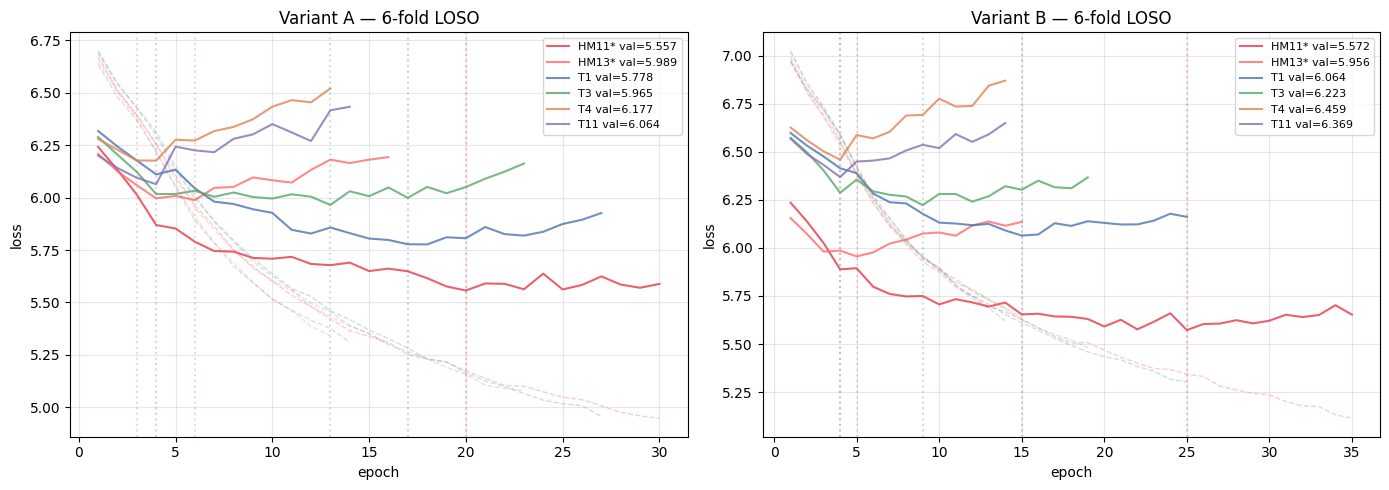

Saved stage2_training_curves.png


In [51]:
# Training curves per variant
fig, axes = plt.subplots(1, len(results), figsize=(7 * len(results), 5), squeeze=False)
COLORS = ["#E63946", "#FF6B6B", "#4C72B0", "#55A868", "#DD8452", "#8172B2"]
LBL = ["HM11*", "HM13*", "T1", "T3", "T4", "T11"]
for ax, (variant, fr) in zip(axes[0], results.items()):
    for i, r in enumerate(fr):
        ep = np.arange(1, len(r["vl_hist"]) + 1)
        ax.plot(ep, r["tr_hist"], color=COLORS[i], alpha=0.25, ls="--", lw=1)
        ax.plot(ep, r["vl_hist"], color=COLORS[i], alpha=0.8, lw=1.5,
                label=f"{LBL[i]} val={r['best_val']:.3f}")
        ax.axvline(r["best_epoch"], color=COLORS[i], ls=":", alpha=0.3)
    ax.set_title(f"Variant {variant} — 6-fold LOSO")
    ax.set_xlabel("epoch"); ax.set_ylabel("loss"); ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(cfg.output_dir, "stage2_training_curves.png"), dpi=200, bbox_inches="tight")
plt.show()
print("Saved stage2_training_curves.png")


In [52]:
# Cohort-transfer test + final all-spot embeddings (winner variant)
def pick_winner():
    if len(results) == 1:
        return next(iter(results))
    a = np.nan_to_num(summary["A"]["probe_rho_resid_mean"])
    b = np.nan_to_num(summary["B"]["probe_rho_resid_mean"])
    return "B" if b > a else "A"

winner = pick_winner()
use_aux = (winner == "B")
mean_best_ep = int(np.round(np.mean(summary[winner]["best_epochs"])))
print(f"Winner = Variant {winner} | cohort/final epochs = {mean_best_ep}")

# Cohort-transfer: train all PT, val both HM (no early stopping, locked length)
print(f"\n{'='*64}\n  COHORT-TRANSFER (train PT, val HM) — Variant {winner}\n{'='*64}")
ct = train_fold(winner, COHORT_FOLD_DEF, "cohort", n_epochs=mean_best_ep, early_stop=False)
print_retrieval(ct["ret_excl"], title=f"COHORT-TRANSFER HM RETRIEVAL (neighbour-excluded) — Variant {winner}")
cohort_val = ct["vl_hist"][-1]
print(f"  cohort val loss = {cohort_val:.4f} | LOSO mean = {summary[winner]['mean_val']:.4f} "
      f"| gap = {cohort_val - summary[winner]['mean_val']:+.4f}")

# Final model: retrain on ALL 6 samples for Phase B
print(f"\n{'='*64}\n  FINAL MODEL — all 6 samples — Variant {winner}\n{'='*64}")
all_idx = np.arange(len(pairs))
sampler = make_balanced_sampler(all_idx) if cfg.balanced_sampling else None
final_loader = DataLoader(full_dataset, batch_size=cfg.batch_size, sampler=sampler,
                          shuffle=(sampler is None), drop_last=True,
                          num_workers=cfg.num_workers, pin_memory=True)
final_model = build_model(use_aux)
opt = torch.optim.AdamW(final_model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
sched = make_warmup_cosine(opt, min(cfg.warmup_epochs, max(mean_best_ep - 1, 1)), mean_best_ep, 0.01)
scaler = torch.amp.GradScaler("cuda", enabled=(cfg.amp and device.type == "cuda"))
for ep in range(1, mean_best_ep + 1):
    tl = run_epoch(final_model, final_loader, cfg, opt, scaler, train=True, use_aux=use_aux)
    sched.step()
    print(f"  final ep {ep:03d}/{mean_best_ep} train={tl:.4f}")
torch.save(final_model.state_dict(), os.path.join(cfg.output_dir, f"final_model_{winner}.pt"))


Winner = Variant A | cohort/final epochs = 10

  COHORT-TRANSFER (train PT, val HM) — Variant A
  model params: 1,592,579  (use_aux=False)


train:   0%|          | 0/26 [00:00<?, ?it/s]

val :   0%|          | 0/11 [00:00<?, ?it/s]

    [A] Ep 001 train=6.7008 val=6.2565


train:   0%|          | 0/26 [00:00<?, ?it/s]

...

  final ep 008/10 train=5.6569


train:   0%|          | 0/36 [00:00<?, ?it/s]

  final ep 009/10 train=5.6078


train:   0%|          | 0/36 [00:00<?, ?it/s]

  final ep 010/10 train=5.5798


In [53]:
# Project ALL spots with final model -> all_spots_embeddings.pt (Phase B input)
all_loader = DataLoader(full_dataset, batch_size=cfg.batch_size, shuffle=False,
                        drop_last=False, num_workers=cfg.num_workers, pin_memory=True)
V, G, C, ids = extract_projections(final_model, all_loader)
print(f"Projected {len(ids):,} spots -> vision{tuple(V.shape)} gene{tuple(G.shape)} cell{tuple(C.shape)}")

# all-spot retrieval sanity (neighbour-excluded)
print_retrieval(
    {n: retrieval_report(q, g, spot_rows, spot_cols, spot_samples, R=cfg.retrieval_excl_radius)
     for n, (q, g) in {"v->g": (V, G), "g->v": (G, V), "v->c": (V, C),
                       "c->v": (C, V), "g->c": (G, C), "c->g": (C, G)}.items()},
    title="FINAL MODEL — ALL-SPOT RETRIEVAL (neighbour-excluded sanity)")

torch.save({
    "ids": ids, "vision_emb": V, "gene_emb": G, "cell_emb": C,
    "spot_samples": list(spot_samples),
    "rows": list(spot_rows.astype(int)), "cols": list(spot_cols.astype(int)),
    "variant": winner, "proj_dim": cfg.proj_dim,
}, os.path.join(cfg.output_dir, "all_spots_embeddings.pt"))
print(f"\nSaved all_spots_embeddings.pt (variant {winner}) -> Phase B input")

# Save config + summary alongside
with open(os.path.join(cfg.output_dir, "config.json"), "w") as f:
    json.dump(asdict(cfg), f, indent=2)
print("Stage 2 complete. Artefacts in:", cfg.output_dir)


extract:   0%|          | 0/37 [00:00<?, ?it/s]

Projected 18,859 spots -> vision(18859, 128) gene(18859, 128) cell(18859, 128)

-- FINAL MODEL — ALL-SPOT RETRIEVAL (neighbour-excluded sanity) --
  pair        R@1      R@5     R@10      MRR
  v->g     0.0008   0.0048   0.0107   0.0060
  g->v     0.0020   0.0079   0.0155   0.0087
  v->c     0.0006   0.0026   0.0052   0.0035
  c->v     0.0006   0.0032   0.0062   0.0043
  g->c     0.0011   0.0042   0.0083   0.0052
  c->g     0.0005   0.0039   0.0073   0.0048

Saved all_spots_embeddings.pt (variant A) -> Phase B input
Stage 2 complete. Artefacts in: /kaggle/working/stage2


In [54]:
import shutil

# Zip the entire stage2 folder into a single archive
shutil.make_archive('/kaggle/working/stage2_UNI2h_ckpts', 'zip', '/kaggle/working/bridge_ckpts')
shutil.make_archive('/kaggle/working/stage2_UNI2h_outputs', 'zip', '/kaggle/working/stage2')

print("Zipping complete! Refresh your output file viewer on the right to see 'stage2_outputs.zip'.")

Zipping complete! Refresh your output file viewer on the right to see 'stage2_outputs.zip'.
